# Paraphrase vs Scaffolding GSM8K Prompts

This notebook demonstrates the dataset-construction script behind the **Paraphrase vs Scaffolding GSM8K Prompts** artifact.

The prior "relevant elaboration" prompt condition (GSM8K question + generic added text) is decomposed into two isolated sub-conditions, for each of 8 hand-picked GSM8K test-split seed problems:

- **`paraphrase_only`** — a pure reworded restatement of the problem (same numbers/constraints/question), padded with generic numerically-inert filler sentences to hit the ~250-added-token "medium" length tier used by the prior elaboration condition.
- **`paraphrase_scaffolding`** — the identical paraphrase plus the same generic verification-scaffolding sentences used in the original elaboration condition ("double-check your units...", "verify each step...", "make sure the final answer is consistent...").

Construction is fully deterministic (no LLM calls): paraphrases are hand-written, filler/scaffolding are appended/trimmed to hit a token-length tolerance band, and every prompt is checked for zero numeric leakage (no digits introduced beyond the original problem's own numbers) via regex. This lets a downstream experiment isolate whether prompt-length-related answer destabilization is driven by the paraphrase itself or by the added scaffolding text.

The notebook loads the demo data (built by the same script), reproduces the construction logic on it, and visualizes token-length matching and hop-count diversity across the two conditions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tiktoken, loguru -- NOT pre-installed on Colab, always install (pinned to data.py's requires)
_pip('tiktoken')
_pip('loguru')

# matplotlib -- pre-installed on Colab, install locally only (to match Colab's exact version)
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Original imports from data.py, plus matplotlib for the results visualization
import json
import re
import sys
from pathlib import Path

from loguru import logger
import tiktoken

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

enc = tiktoken.get_encoding("cl100k_base")

## Load the demo data

`mini_demo_data.json` is the finished output of `data.py` (the artifact's dataset-build script) -- all 16 rows (8 seeds x 2 sub-conditions), following the `exp_sel_data_out` schema. We load it from GitHub with a local-file fallback so this notebook works both in Colab and locally.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-0e9809-interpretive-load-not-token-count-drives/main/round-2/dataset-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples from dataset={data['datasets'][0]['dataset']!r}")
print(f"Seed indices: {data['metadata']['seed_indices']}")

Loaded 16 examples from dataset='openai/gsm8k'
Seed indices: [0, 1, 7, 15, 23, 41, 58, 77]


## Config

These are the same tunable constants used by `data.py` to build the dataset: the target number of "medium-tier" added tokens, and the tolerance band around that target. The demo data already contains all 8 seeds (16 rows) -- the smallest unit the construction script operates on is one seed pair, so no further down-scaling is needed; these constants control the verification checks re-run below.

In [5]:
# Same constants as data.py
MEDIUM_TIER_TARGET = 250  # cl100k_base tokens, matching prior 'medium' tier
TOLERANCE_ABS = 15
TOLERANCE_REL = 0.10

N_SEEDS_TO_CHECK = len(examples) // 2  # number of seed pairs to run verification on (max = all 8)

## Core construction/verification helpers

These are copied verbatim from `data.py`: `tok_len` (cl100k_base token count) and `in_tolerance` (checks whether the number of added tokens falls within `max(TOLERANCE_ABS, target * TOLERANCE_REL)` of the medium-tier target). These are exactly the functions the build script uses to decide whether a paraphrase/scaffolding pair is length-matched.

In [6]:
def tok_len(text: str) -> int:
    return len(enc.encode(text))


def in_tolerance(added_tokens: int, target: int = MEDIUM_TIER_TARGET) -> bool:
    band = max(TOLERANCE_ABS, target * TOLERANCE_REL)
    return abs(added_tokens - target) <= band


def numeric_leakage_ok(added_text: str, original_numbers: set) -> bool:
    """Flag any digit sequence in added text not present in the original
    problem's number set (scaffolding sentences are non-numeric by
    construction, so any hit here is a real leak)."""
    found = set(re.findall(r"\d+(?:\.\d+)?", added_text))
    return len(found - original_numbers) == 0

## Re-run the tolerance and numeric-leakage checks

For each of the `N_SEEDS_TO_CHECK` seed pairs, we recompute the token count of the stored prompt with the exact same tokenizer the build script used, and confirm it still falls inside the tolerance band around the medium-tier target. We also re-run the numeric-leakage check for the scaffolding text (pulled from `data["metadata"]["scaffolding_text"]`, which the build script wrote out verbatim) against the set of numbers present in that seed's `paraphrase_only` prompt -- reproducing exactly what `build_pair()` in `data.py` asserted before the dataset was allowed to ship.

In [7]:
SCAFFOLDING = data["metadata"]["scaffolding_text"]

# group rows by seed_id -> {paraphrase_only: row, paraphrase_scaffolding: row}
by_seed = {}
for row in examples:
    by_seed.setdefault(row["metadata_seed_id"], {})[row["metadata_content_type"]] = row

report = []
for seed_id in list(by_seed.keys())[:N_SEEDS_TO_CHECK]:
    pair = by_seed[seed_id]
    para_row = pair["paraphrase_only"]
    scaf_row = pair["paraphrase_scaffolding"]

    recomputed_para_tok = tok_len(para_row["input"])
    recomputed_scaf_tok = tok_len(scaf_row["input"])

    original_numbers = set(re.findall(r"\d+(?:\.\d+)?", para_row["input"]))
    leak_scaffold = numeric_leakage_ok(SCAFFOLDING, original_numbers)

    report_row = {
        "seed_id": seed_id,
        "n_hops": para_row["metadata_n_hops"],
        "paraphrase_only_tokens": recomputed_para_tok,
        "paraphrase_only_tokens_match_stored": recomputed_para_tok == para_row["metadata_token_count"],
        "paraphrase_only_added_tokens": para_row["metadata_added_token_count"],
        "paraphrase_only_in_tolerance": in_tolerance(para_row["metadata_added_token_count"]),
        "paraphrase_scaffolding_tokens": recomputed_scaf_tok,
        "paraphrase_scaffolding_tokens_match_stored": recomputed_scaf_tok == scaf_row["metadata_token_count"],
        "paraphrase_scaffolding_added_tokens": scaf_row["metadata_added_token_count"],
        "paraphrase_scaffolding_in_tolerance": in_tolerance(scaf_row["metadata_added_token_count"]),
        "paraphrase_scaffolding_leakage_clean": leak_scaffold,
    }
    report.append(report_row)
    logger.debug(f"{seed_id}: {report_row}")

logger.info(f"Re-verified {len(report)} seed pairs")

16:30:36|INFO   |Re-verified 8 seed pairs


## Results

All checks should PASS (both conditions land inside the tolerance band around the 250-token medium tier, and the scaffolding text introduces zero new numbers). Below: a pass/fail table, plus a bar chart comparing added-token counts across the two conditions per seed (showing they're length-matched) alongside each seed's reasoning-hop count (showing seed diversity).

ALL CHECKS PASS: True

seed_id          n_hops  para_added  para_ok  scaf_added  scaf_ok  leak_ok
--------------------------------------------------------------------------
gsm8k_test_0          2         239     True         272     True     True
gsm8k_test_1          2         234     True         267     True     True
gsm8k_test_7          4         236     True         269     True     True
gsm8k_test_15         3         234     True         267     True     True
gsm8k_test_23         2         240     True         273     True     True
gsm8k_test_41         2         236     True         269     True     True
gsm8k_test_58         2         231     True         264     True     True
gsm8k_test_77         2         234     True         267     True     True


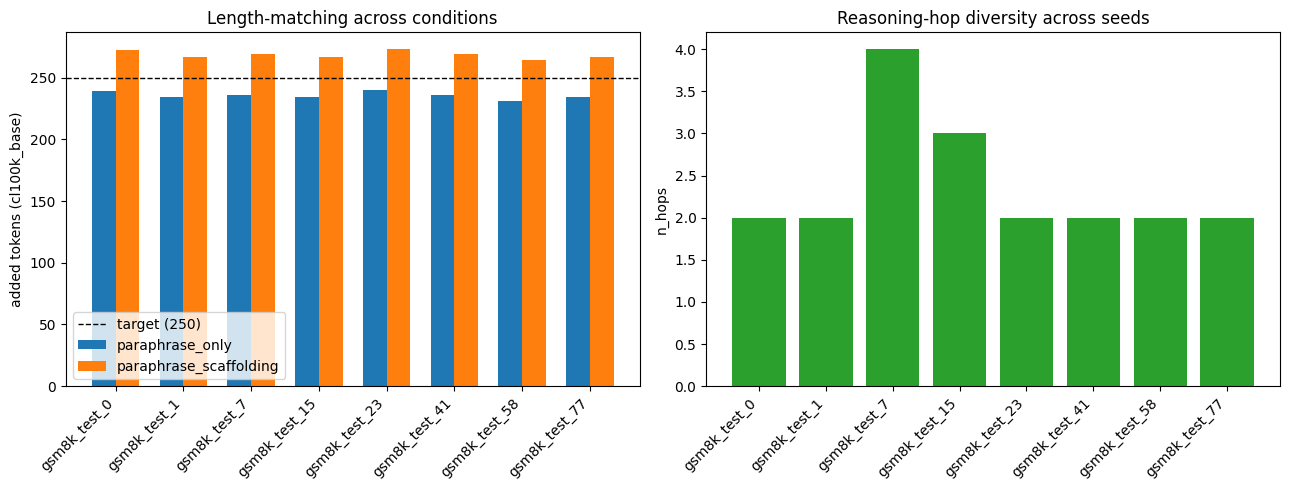

In [8]:
all_pass = all(
    r["paraphrase_only_tokens_match_stored"] and r["paraphrase_only_in_tolerance"]
    and r["paraphrase_scaffolding_tokens_match_stored"] and r["paraphrase_scaffolding_in_tolerance"]
    and r["paraphrase_scaffolding_leakage_clean"]
    for r in report
)
print(f"ALL CHECKS PASS: {all_pass}\n")

header = f"{'seed_id':<16}{'n_hops':>7}{'para_added':>12}{'para_ok':>9}{'scaf_added':>12}{'scaf_ok':>9}{'leak_ok':>9}"
print(header)
print("-" * len(header))
for r in report:
    print(
        f"{r['seed_id']:<16}{r['n_hops']:>7}"
        f"{r['paraphrase_only_added_tokens']:>12}{str(r['paraphrase_only_in_tolerance']):>9}"
        f"{r['paraphrase_scaffolding_added_tokens']:>12}{str(r['paraphrase_scaffolding_in_tolerance']):>9}"
        f"{str(r['paraphrase_scaffolding_leakage_clean']):>9}"
    )

seed_ids = [r["seed_id"] for r in report]
para_added = [r["paraphrase_only_added_tokens"] for r in report]
scaf_added = [r["paraphrase_scaffolding_added_tokens"] for r in report]
n_hops = [r["n_hops"] for r in report]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = range(len(seed_ids))
width = 0.35
ax1.bar([i - width / 2 for i in x], para_added, width, label="paraphrase_only")
ax1.bar([i + width / 2 for i in x], scaf_added, width, label="paraphrase_scaffolding")
ax1.axhline(MEDIUM_TIER_TARGET, color="black", linestyle="--", linewidth=1, label=f"target ({MEDIUM_TIER_TARGET})")
ax1.set_xticks(list(x))
ax1.set_xticklabels(seed_ids, rotation=45, ha="right")
ax1.set_ylabel("added tokens (cl100k_base)")
ax1.set_title("Length-matching across conditions")
ax1.legend()

ax2.bar(seed_ids, n_hops, color="tab:green")
ax2.set_xticks(range(len(seed_ids)))
ax2.set_xticklabels(seed_ids, rotation=45, ha="right")
ax2.set_ylabel("n_hops")
ax2.set_title("Reasoning-hop diversity across seeds")

plt.tight_layout()
plt.show()